# Медицина.
## Анализ факторов развития болезни

Коробовцева Ольга  
Лоза Александр  
Павлова Анна  

## Установка и импорт необходимых библиотек


В проекте используются: numpy, pandas, matplotlib, seaborn, sklearn, catboost

In [58]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn ipywidgets ipython catboost

In [ ]:
import pandas as pd                     
import numpy as np                      
import matplotlib.pyplot as plt         
import seaborn as sns                   
import scipy.stats as stats             
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.dummy import DummyRegressor

In [ ]:
%matplotlib inline

## 2. Предобработка данных

### 2.2 Исправление неправильных символов в датасете, кодирование категориальных переменных


In [ ]:
def fix_types(df: pd.DataFrame) -> None:
    df["развитие_опп"] = df["развитие_опп"].apply(lambda x: 0 if x == "нет" else 1)
    df["хбп"] = df["хбп"].apply(lambda x: 0 if x == "Пациенты без ХБП" else 1 if x == "Стадия C1-C2" else 2)
    for column in df.select_dtypes(include=["object"]).columns:
        df[column] = df[column].apply(lambda x: float(x.replace(",", ".").replace("o", "0")) if type(x) != float else x)

### 2.3 Поиск и удаление выбросов

In [ ]:
def drop_outliers(df: pd.DataFrame, a=5) -> tuple:
    columns = df.columns
    outliers_all = np.array([False for i in range(len(df))])
    for column in columns:
        if len(df[column].unique()) > len(df) * 0.05:
            std = df[column].std()
            median = df[column].median()
            outliers = abs(df[[column]] - median) > a * std
            outliers_all = np.bitwise_or(outliers.to_numpy().flatten(), outliers_all)
    df_unchanged = df.copy()
    df = df[~ outliers_all].dropna()
    return df, df_unchanged, outliers_all

### 2.4 Удаление строк, содержащих пропуски

In [ ]:
def drop_nan(df: pd.DataFrame) -> None:
    missing_data = df.loc[df.isnull().any(axis=1)]
    missing_data.to_csv('missing_data.csv', index=True)
    df.dropna(inplace=True)

Удаление строк с NaN. Создание файйла missing_data.csv с пациентами, которым нужно сдать некоторые анализы.

### 2.5 Удаление дубликатов

In [ ]:
def check_duplicates(df: pd.DataFrame) -> None:
    df.drop_duplicates(inplace=True)

### 2.6 Сформировать дополнительный столбец АИК && переливание крови

In [ ]:
def add_column(df: pd.DataFrame) -> None:
    df["аик+переливание_крови"] = df["аик"] * (df["объем_гемотрансфузии"].apply(lambda x: 1 if x > 0 else 0))

#### Обработка исходных данных(вкл п 2.1)

In [ ]:
def preprocess(df_name: str) -> pd.DataFrame:
    df = pd.read_csv(df_name)
    df.columns = [x.lower().replace(" ", "_").replace(",", "") for x in df.columns]
    df.columns = [x[:-1] if x[-1] == "_" else x for x in df.columns]
    fix_types(df)
    drop_nan(df)
    check_duplicates(df)
    df, unchanged_df, outliers = drop_outliers(df)
    add_column(df)
    return df.reset_index()

### Вызов функции п. 2

In [ ]:
df = preprocess("medics_1.csv")
df

,index,развитие_опп,хбп,возраст,пол,гб,сахарный_диабет,стенокардия,инфаркт_миокарда,мерцательная_аритмия,...,аик,количество_шунтов,длительность_операции,длительность_аик,время_пережатия_аорты,объем_кровопотерии,объем_гемотрансфузии,объем_инфузий,диурез,аик+переливание_крови
0,3,0,1,62,1,1,0,1,1,1,...,1,3,210,71,43,500,1283,1700,1700,1
1,4,1,1,55,1,1,1,1,1,0,...,1,3,265,116,74,500,1560,1800,1300,1
2,5,0,0,60,1,1,0,1,1,0,...,1,3,240,74,62,200,1350,2100,1800,1
3,8,0,1,60,1,1,0,1,0,0,...,1,3,299,122,75,500,600,1050,4000,1
4,9,1,1,58,1,1,1,1,0,1,...,1,2,185,64,55,500,540,1200,700,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,194,0,0,47,1,1,0,1,0,0,...,1,3,290,98,55,250,1094,1200,2000,1
133,196,1,1,68,1,1,0,1,0,1,...,0,2,220,0,0,150,0,1400,2000,0
134,197,1,1,72,1,1,0,1,1,0,...,1,4,270,88,70,500,1379,1300,2300,1
135,198,0,1,71,0,1,0,1,1,0,...,1,3,280,73,61,200,2360,900,2000,1


## 3. Проведение расчётов и исследований

### Вспомогательная функция

Функция для проверки, является ли столбец категориальным

In [ ]:
def is_categorical(df: pd.DataFrame, column: str) -> bool:
    return len(df[column].unique()) < len(df) * 0.05


### 3.1 Рассчет процента пациентов с хроническими заболеваниями для групп “есть ОПП/нет ОПП”
Подсчет комбинаций *"хроническая болезнь + развитие опп"*

In [ ]:
def count_disease(df: pd.DataFrame, imt: str) -> list:
    lst = ["гб", "стенокардия", "инфаркт_миокарда", "желудочковая_экстрасистолия",
           "мерцательная_аритмия", "хсн", "нк"]
    answer = []
    for i in range(len(lst)):
        answer.append(df.loc[(df['имт_ном'] == imt) & (df[lst[i]] == 1), 'развитие_опп'].sum())
    return answer

Графическое отображение вышеописанной функции с использованием *pie chart*

In [ ]:
def draw_chart(labels, sizes, name, fig, ax, row, column):
        colors = ['#506D2F', '#2a2922', '#f3ebdd', '#7d5642', "#626D71", "#cdcdc0", "#DDBC95"]

        wedges, texts = ax[row][column].pie(sizes, startangle=-40, colors=colors)

        centre_circle = plt.Circle((0, 0), 0.70, fc='white')
        fig = plt.gcf()
        fig.gca().add_artist(centre_circle)

        ax[row][column].legend(wedges, labels,
                title="болезни",
                loc="center left",
                bbox_to_anchor=(1, 0, 0.5, 1))

        plt.setp(texts, size=12, weight="bold")
        ax[row][column].pie(sizes, labels=labels, colors=colors,
                autopct='%1.1f%%')
        ax[row][column].set_title(name)


### 3.2 Ввод нового фактора на основе столбца “Индекс массы тела”. Количество пациентов, имеющих проблемы с сердцем для каждой группы.
Введение нового фактора **"имт_ном"**. Функция считывает значение "имт" из датасета, обрабатывает и записывает соответствующее номинальное значение.

Выбор и классификация болезней, которые оказывают влияние на сердце:
* Болезни, ведущие к сердечным заболеваниям
    + Гипертония
    + Сахарный диабет
* Синдромы
    + Стенокардия
* Болезни сердца
    + Инфаркт миокарда
    + Желудочковая экстрасистолия
    + Мерцательная аритмия
    + Хроническая сердечная недостаточность
    + Недостаточность кровообращения
    
Отосительно перечисленных болезней были найдены зависимости относительно нового каждой группы из **"имт_ном"**
    

In [ ]:
def imt(df):

    # Подпункт 2
    df["имт_ном"] = df["имт"].apply(lambda x: "выраженный_дефицит_массы_тела" if x < 16
                                    else "недостаточная_масса_тела" if 16 <= x < 18.5
                                    else "норма" if 18.5 <= x < 25
                                    else "избыточная_масса_тела" if 25 <= x < 30
                                    else "ожирение_1_степени" if 30 <= x < 35
                                    else "ожирение_2_степени" if 35 <= x < 40
                                    else "ожирение_3_степени")
    
    labels = ["ГБ", "Стенокардия", "Инфаркт миокарда", "Желудочковая экстрасистолия", "Мерцательная аритмия",
              "ХСН", "НК"]

    sizes_norma = count_disease(df, "норма")
    sizes_overweight = count_disease(df, "избыточная_масса_тела")
    sizes_one = count_disease(df, "ожирение_1_степени")
    sizes_two = count_disease(df, "ожирение_2_степени")
    fig, ax = plt.subplots(2, 2, figsize=(36, 18))

    draw_chart(labels, sizes_norma, "норма", fig, ax, 0, 0)
    draw_chart(labels, sizes_overweight, "избыточная_масса_тела", fig, ax, 0, 1)
    draw_chart(labels, sizes_one, "ожирение_1_степени", fig, ax, 1, 0)
    draw_chart(labels, sizes_two, "ожирение_2_степени", fig, ax, 1, 1)
    plt.show()

Подсчет процент пациентов с хроническими заболеваниям:
* Сахарный диабет
* Гипертония
* Хроническая болезнь почек

Для групп: *"есть ОПП", "нет ОПП"*

In [ ]:
def chronic_diseases(df: pd.DataFrame) -> None:
    # Подпункт 1
    
    diabetes_mellitus_true = round(((df.loc[df['развитие_опп'] == 1, 'сахарный_диабет']
                                     .sum()) / (sum(df["развитие_опп"]))) * 100, 4)
    diabetes_mellitus_false = round(((df.loc[df['развитие_опп'] == 0, 'сахарный_диабет']
                                      .sum()) / (len(df['развитие_опп']) - sum(df["развитие_опп"]))) * 100, 4)

    hypertension_true = round(((df.loc[df['развитие_опп'] == 1, 'гб']
                                .sum()) / (sum(df["развитие_опп"]))) * 100, 4)
    hypertension_false = round(((df.loc[df['развитие_опп'] == 0, 'гб']
                                 .sum()) / (len(df['развитие_опп']) - sum(df["развитие_опп"]))) * 100, 4)

    df["хбп_бин"] = df["хбп"].apply(lambda x: 1 if x == 1 or x == 2 else 0)
    chronic_kidney_disease_true = round(((df.loc[df['хбп_бин'] == 1, 'развитие_опп']
                                          .sum()) / (sum(df["развитие_опп"]))) * 100, 4)
    chronic_kidney_disease_false = round(((df.loc[df['развитие_опп'] == 0, 'хбп_бин']
                                           .sum()) / (len(df['развитие_опп']) - sum(df["развитие_опп"]))) * 100, 4)

    print(str(diabetes_mellitus_true) + "%", str(diabetes_mellitus_false) + "%")
    print(str(hypertension_true) + "%", str(hypertension_false) + "%")
    print(str(chronic_kidney_disease_true) + "%", str(chronic_kidney_disease_false) + "%")
 

#### Визуализация результатов анализа

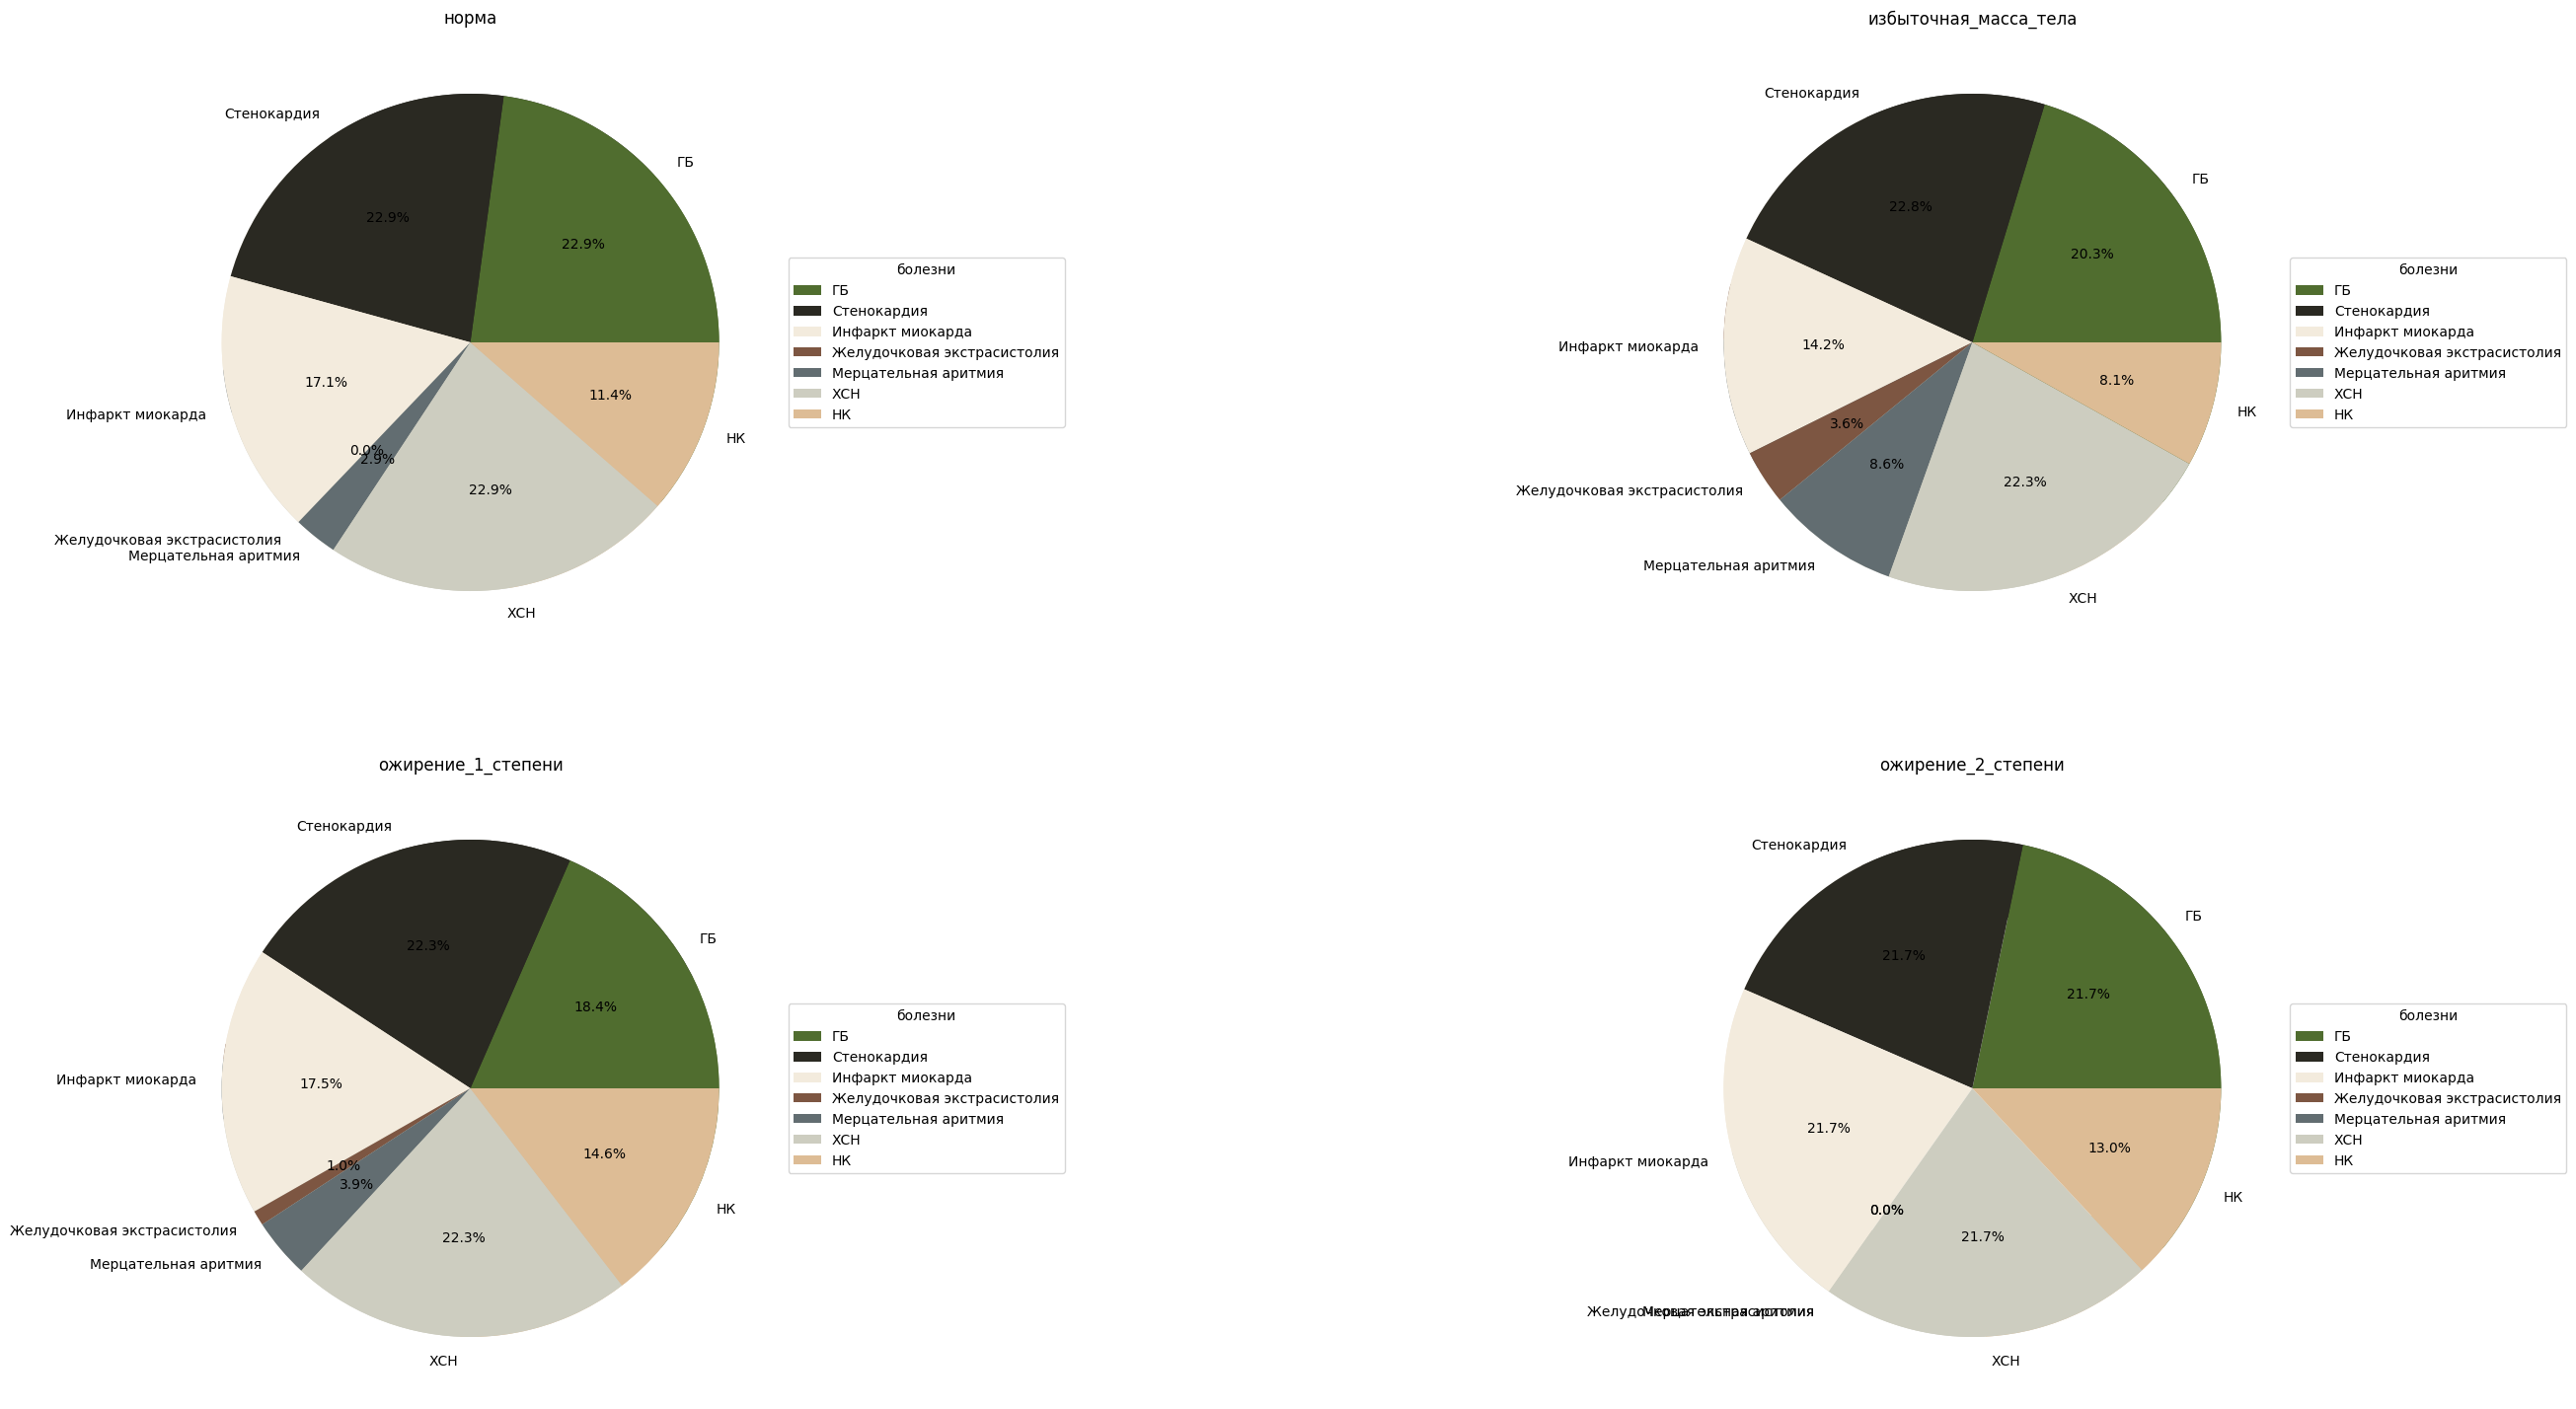

In [ ]:
imt(df)

### 3.3 Исследование зависимости длительности операции от факта перенесенного в прошлом инфаркта миокарда.

In [ ]:
def dependence_time_fact(df: pd.DataFrame) -> None:
    pointbiserial_v = stats.pointbiserialr(df["инфаркт_миокарда"], df["длительность_операции"])
    print(f"Точечно-бисериальная корреляция: статистика:{pointbiserial_v[0]}, p-уровень:{pointbiserial_v[1]}")
    mannwhitneyu_v = stats.mannwhitneyu(df["инфаркт_миокарда"], df["длительность_операции"])
    print(f"Манна-Уитни: статистика:{mannwhitneyu_v[0]}, p-уровень:{mannwhitneyu_v[1]}")
    infarct_0 = df[df["инфаркт_миокарда"] == 0]
    infarct_1 = df[df["инфаркт_миокарда"] == 1]
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    plot = sns.boxplot(ax=axes[0], data=infarct_0, y="длительность_операции", palette='Greens')
    plot2 = sns.boxplot(ax=axes[1], data=infarct_1, y="длительность_операции", palette='Greens')
    plt.show()
    print("По данному датасету зависимость выявить не удалось.")

P-уровень - большой, статистика - незначительная => корреляции не выявлено.

### 3.4 Проверка гипотезы: "Верно ли, что у пациентов с ИМТ выше нормы будет повышенный уровень холестерина?"

In [ ]:
def imt_hol(df: pd.DataFrame) -> None:
    df["ктг_имт"] = df["имт"].apply(lambda x: 1 if x > 25 else 0)
    df["ктг_холестерин"] = df["холестерин"].apply(lambda x: 1 if x > 7.8 else 0)
    imt_hol = pd.crosstab(df['ктг_имт'], df['ктг_холестерин'])
    chi_2_v = stats.chi2_contingency(pd.crosstab(df['ктг_имт'], df['ктг_холестерин']))
    print(f"Хи-квадрат: статистика:{chi_2_v[0]}, p-уровень:{chi_2_v[1]}")
    sns.heatmap(imt_hol, cmap="YlGnBu", annot=True, cbar=False);
    plt.show()
    print("По данному датасету подтвердить гипотезу не удалось.")

Гипотезу подтвердить не представляется возможным, т.к. пациентов с холестерином выше нормы на порядок меньше, чем тех у кого в пределах нормы.
По аналитическому и графическому методам кореляция не выявлена. 

### 3.5 Проверка гипотезы: "Верно ли, что даже без хронических болезней почек с возрастом толщина паренхимы почек уменьшается?"

In [ ]:
def poch_paren(df: pd.DataFrame) -> None:
    poch_paren = df[df["хбп"] == 0]
    pearson_v = stats.pearsonr(poch_paren["толщина_паренхимы_почек"], poch_paren["возраст"])
    print(f"Пирсон: статистика:{pearson_v[0]}, p-уровень:{pearson_v[1]}")
    sns.scatterplot(data=poch_paren, x="толщина_паренхимы_почек", y="возраст", hue="возраст", palette='Greens')
    plt.show()
    print("По данному датасету подтвердить гипотезу не удалось.")

Значение корреляции мало, а p-уровень больше 0.5, аналитическим путем зависимость доказать по данным анализам невозможно. Графически тенденции уменьшения паренхимы почек с возрастом не наблюдается.

### 3.6 Проверка адекватности поставленного диагноза по стадии хронической болезни почек.

Функция для получения стадии ХБП по СКФ

In [ ]:
def get_diagnosis(m: int) -> str:
    if m > 100:
        return "Пациенты без ХБП"
    if m > 60:
        return "Стадия C1-C2"
    return "Стадия С3"


Проверка стадии ХБП по СКФ

In [ ]:
def check_diagnosis(df: pd.DataFrame) -> list:  # ?
    num_to_words = {0: "Пациенты без ХБП", 1: "Стадия C1-C2", 2: "Стадия С3"}
    wrong_diagnosis = []
    for idx, row in df.iterrows():
        if row["скф_расч."] > 90:
            if row["хбп"] != 0 and row["хбп"] != 1:
                print(
                    f"У пациента {idx} диагноз {num_to_words[row['хбп']]}, но должен быть {get_diagnosis(row['скф_расч.'])}")
                wrong_diagnosis.append(idx)
        elif row["скф_расч."] > 60:
            if row["хбп"] != 1:
                print(
                    f"У пациента {idx} диагноз {num_to_words[row['хбп']]}, но должен быть {get_diagnosis(row['скф_расч.'])}")
                wrong_diagnosis.append(idx)
        elif row["хбп"] != 2:
            print(
                f"У пациента {idx} диагноз {num_to_words[row['хбп']]}, но должен быть {get_diagnosis(row['скф_расч.'])}")
            wrong_diagnosis.append(idx)
    return wrong_diagnosis

### 3.7 Подсчёт корреляции между факторами и целевой переменной.

In [ ]:
def check_correlations(df: pd.DataFrame) -> list:
    columns = ["возраст", "сахарный_диабет", "гб", "хбп", "сад", "дад", "чсс", "рн", "фракция_изгнания", "холестерин",
               "креатинин_крови", "мочевина", "скф_расч.", "калий", "имт", "толщина_паренхимы_почек"]
    res = []
    for x in columns:
        if is_categorical(df, x):
            temp = stats.chi2_contingency(pd.crosstab(df[x], df["развитие_опп"]))
            res.append([x, "развитие_опп", round(temp[1], 4), "Хи-квадрат"])
        else:
            if stats.shapiro(df[x])[1] > 0.05:
                temp = stats.ttest_ind(df["развитие_опп"], df[x])
                res.append([x, "развитие_опп", round(temp[1], 4), "T-критерий Стьюента"])
            else:
                temp = stats.mannwhitneyu(df["развитие_опп"], df[x])
                res.append([x, "развитие_опп",round(temp[1], 4), "U-критерий Манна-Уитни"])    
    return pd.DataFrame(np.array(res), columns=["Фактор", "Развитие ОПП", "p-уровень", "Метод"])

### Вызов функций

In [ ]:
wrong_diagnsis = check_diagnosis(df)

1 68.0
1 95.0
0 75.0
У пациента 2 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
1 90.0
1 80.0
1 75.0
0 86.0
У пациента 6 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
1 84.0
2 51.0
1 100.0
0 148.0
1 93.0
1 84.0
1 103.7
2 56.0
0 116.0
1 118.0
0 97.0
0 127.0
0 81.0
У пациента 19 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
1 91.5
1 135.0
0 168.0
0 68.0
У пациента 23 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
0 117.0
1 85.0
0 172.0
1 128.0
0 88.0
У пациента 28 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
0 105.0
0 60.0
У пациента 30 диагноз Пациенты без ХБП, но должен быть Стадия С3
1 130.0
1 74.0
1 65.0
0 73.0
У пациента 34 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
1 77.0
1 99.0
1 69.0
2 53.0
0 59.0
У пациента 39 диагноз Пациенты без ХБП, но должен быть Стадия С3
0 81.0
У пациента 40 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
0 68.0
У пациента 41 диагноз Пациенты без ХБП, но должен быть Стадия C1-C2
0 108.0
1 98.0
1 86.0

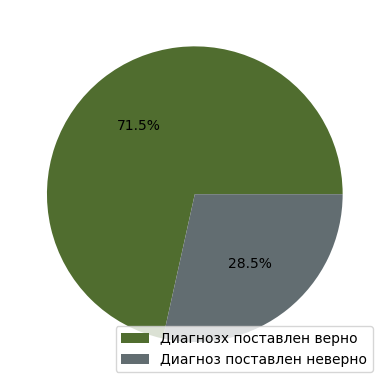

In [ ]:
plt.pie((len(df) - len(wrong_diagnsis), len(wrong_diagnsis)), colors=["#506D2F", "#626D71"], autopct='%1.1f%%')
plt.legend(["Диагнозх поставлен верно", "Диагноз поставлен неверно"], loc="lower right")
plt.show()

Подсчёт p-уровня корреляции между различными факторами

In [ ]:
check_correlations(df)

,Фактор,Развитие ОПП,p-уровень,Метод
0,возраст,развитие_опп,0.0,T-критерий Стьюента
1,сахарный_диабет,развитие_опп,0.142,Хи-квадрат
2,гб,развитие_опп,0.1583,Хи-квадрат
3,хбп,развитие_опп,0.7572,Хи-квадрат
4,сад,развитие_опп,0.0,U-критерий Манна-Уитни
5,дад,развитие_опп,0.0,U-критерий Манна-Уитни
6,чсс,развитие_опп,0.0,U-критерий Манна-Уитни
7,рн,развитие_опп,0.0,U-критерий Манна-Уитни
8,фракция_изгнания,развитие_опп,0.0,U-критерий Манна-Уитни
9,холестерин,развитие_опп,0.0,U-критерий Манна-Уитни


<Axes: >

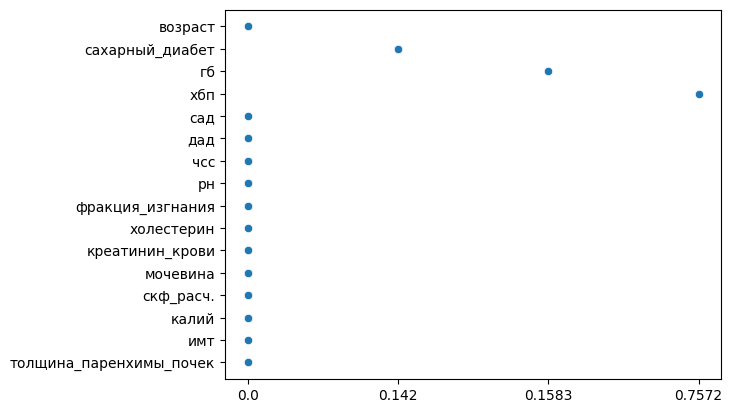

In [ ]:
correlations = check_correlations(df).to_numpy().T
sns.scatterplot(x=correlations[2], y=correlations[0])

Точечно-бисериальная корреляция: статистика:-0.022542961673412756, p-уровень:0.7937268459941984
Манна-Уитни: статистика:0.0, p-уровень:2.4702656905160313e-48


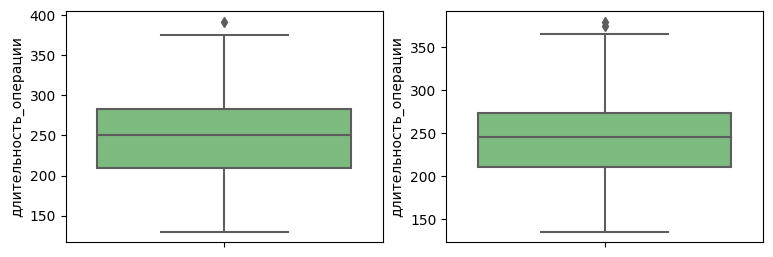

По данному датасету зависимость выявить не удалось.


In [ ]:
dependence_time_fact(df)


Хи-квадрат: статистика:0.062021494708994734, p-уровень:0.8033289503599856


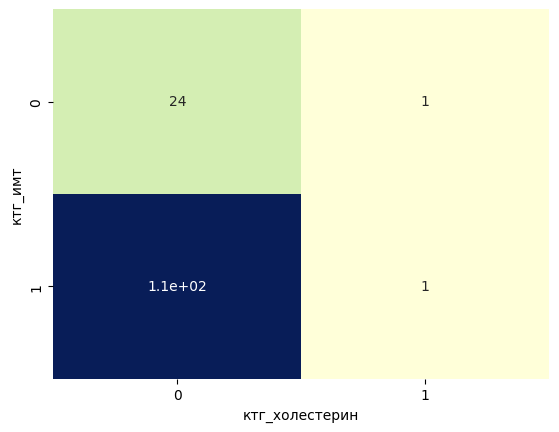

По данному датасету подтвердить гипотезу не удалось.


In [ ]:
imt_hol(df)


Пирсон: статистика:-0.19188428221432793, p-уровень:0.12570235535651592


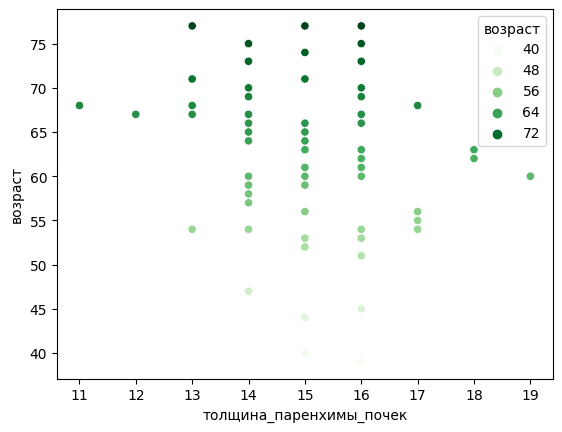

По данному датасету подтвердить гипотезу не удалось.


In [ ]:
poch_paren(df)

# 4. Проверка гипотез

### Общие функции

In [ ]:
def is_normal(df, col_2):
    if stats.shapiro(df[col_2])[1] >= 0.05:
        corr_p =  stats.ttest_ind(df['развитие_опп'], df[col_2])
        print("Критерий: Стьюдента")

    else:
        corr_p =  stats.ttest_ind(df['развитие_опп'], df[col_2])
        print("Критерий: Манна-Уитни")
    print(f"Статистика:{round(corr_p[0], 4)}, p-уровень:{round(corr_p[1], 4)}")
    pointbiserial_v = stats.pointbiserialr(df['развитие_опп'], df["возраст"])
    print("Точечно-бисериальная корреляция")
    print(f"Статистика:{round(pointbiserial_v[0], 4)}, p-уровень:{round(pointbiserial_v[1], 4)}")
    sns.boxplot(data=df, x='развитие_опп', y=col_2, palette='Greens')
    plt.show()

In [ ]:
def chi_2(df, col_2):
    cross_tab = pd.crosstab(df['развитие_опп'], df[col_2])
    c_p =  stats.chi2_contingency(cross_tab)
    print("Критерий: Хи-квадрат")
    print(f"Статистика:{round(c_p[0], 4)}, p-уровень:{round(c_p[1], 4)}")
    sns.heatmap(cross_tab, cmap="YlGnBu", annot=True, cbar=False)
    plt.show()

### Гипотеза №1

Есть ли зависимость между возникновением ОПП и стадией ХБП.

In [ ]:
def hypo_1(df) -> None:  # 'хбп'
    chi_2(df, 'хбп')

### Гипотеза №2

Есть ли зависимость между возникновением ОПП и возрастом пациента.

In [ ]:
def hypo_2(df) -> None:  # 'возраст'
    is_normal(df, "возраст")


### Гипотеза №3

Есть ли зависимость между возникновением ОПП и полом пациента.

In [ ]:

def hypo_3(df) -> None:  # 'пол'
    chi_2(df, 'пол')



### Гипотеза №4

Есть ли зависимость между возникновением ОПП и количеством мочевины в крови.

In [ ]:
def hypo_4(df) -> None:  # 'мочевина'
    is_normal(df, 'мочевина')

### Гипотеза №5

Есть ли зависимость между возникновением ОПП и количеством лейкоцитов.

In [ ]:
def hypo_5(df) -> None:  # 'лейкоциты_крови'
    is_normal(df, 'лейкоциты_крови')

### Гипотеза №6

Есть ли зависимость между возникновением ОПП и количеством тромбоцитов.

In [ ]:
def hypo_6(df) -> None:  # 'тромбоциты'
    is_normal(df, "тромбоциты")

### Гипотеза №7

Есть ли зависимость между возникновением ОПП и количеством общего белка.

In [ ]:
def hypo_7(df) -> None:  # 'общий_белок'
    is_normal(df, "общий_белок")


### Гипотеза №8

Есть ли зависимость между возникновением ОПП и наличием аппарата искусственного кровообращения.

In [ ]:
def hypo_8(df) -> None:  # 'аик'
    chi_2(df, 'аик')


### Гипотеза №9

Есть ли зависимость между возникновением ОПП и объемом гемотрансфузии.

In [ ]:
def hypo_9(df) -> None:  # 'объем_гемотрансфузии'
    is_normal(df, "объем_гемотрансфузии")

### Гипотеза №10

Есть ли зависимость между возникновением ОПП и объемом диуреза.

In [ ]:
def hypo_10(df):  # 'диурез'
    is_normal(df, "диурез")

## Вызов функций

Критерий: Хи-квадрат
Статистика:0.5562, p-уровень:0.7572


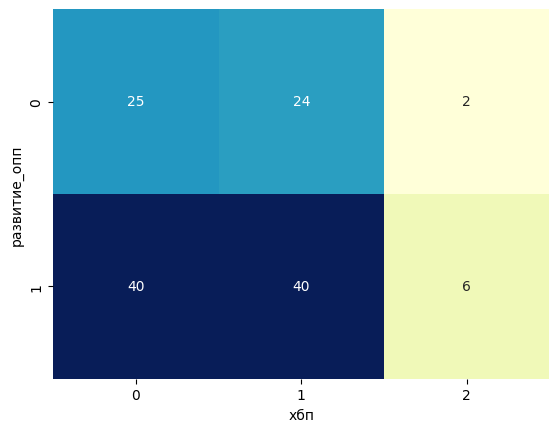

In [ ]:
hypo_1(df)

Гипотеза 1 не подтверждена.

Критерий: Стьюдента
Статистика:-85.556, p-уровень:0.0
Точечно-бисериальная корреляция
Статистика:0.0757, p-уровень:0.3791


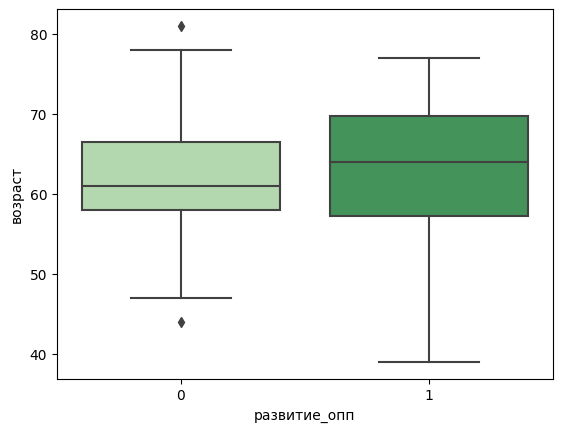

In [ ]:
hypo_2(df)

Гипотеза 2 подтверждена по критерию Стьюдента.

Критерий: Хи-квадрат
Статистика:0.1497, p-уровень:0.6988


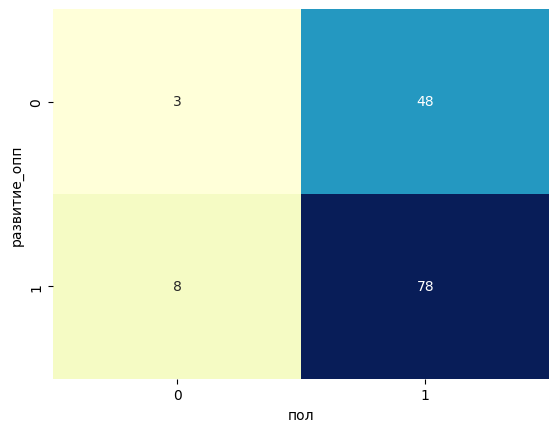

In [ ]:
hypo_3(df)

О гипотезе 3 нерационально что-либо утверждать из-за разных порядков категорий.

Критерий: Манна-Уитни
Статистика:-38.9731, p-уровень:0.0
Точечно-бисериальная корреляция
Статистика:0.0757, p-уровень:0.3791


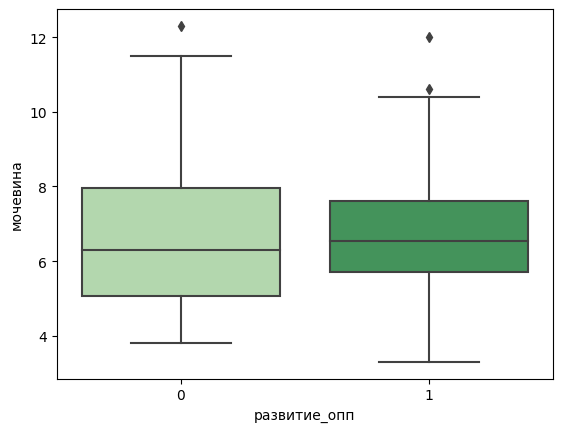

In [ ]:
hypo_4(df)

Гипотеза 4 подтверждена по критерию Манна-Уитни.

Критерий: Манна-Уитни
Статистика:-39.0399, p-уровень:0.0
Точечно-бисериальная корреляция
Статистика:0.0757, p-уровень:0.3791


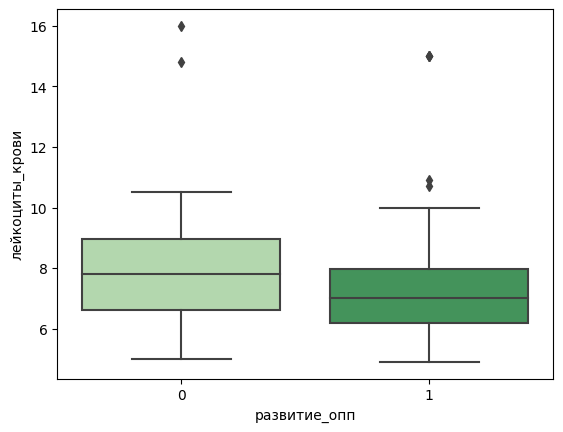

In [ ]:
hypo_5(df)

Гипотеза 5 подтверждена по критерию Манна-Уитни.

Критерий: Манна-Уитни
Статистика:-40.9522, p-уровень:0.0
Точечно-бисериальная корреляция
Статистика:0.0757, p-уровень:0.3791


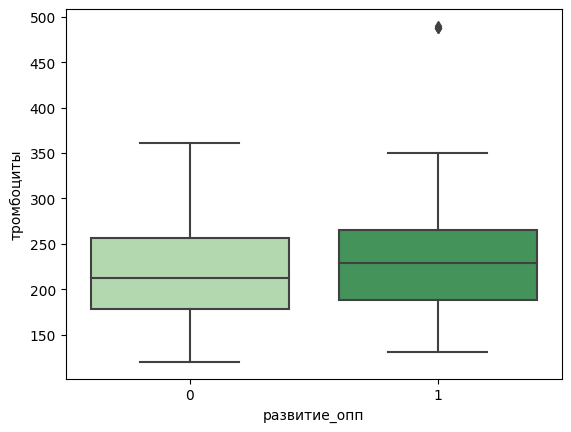

In [ ]:
hypo_6(df)


Гипотеза 6 подтверждена по критерию Манна-Уитни.

Критерий: Стьюдента
Статистика:-184.9113, p-уровень:0.0
Точечно-бисериальная корреляция
Статистика:0.0757, p-уровень:0.3791


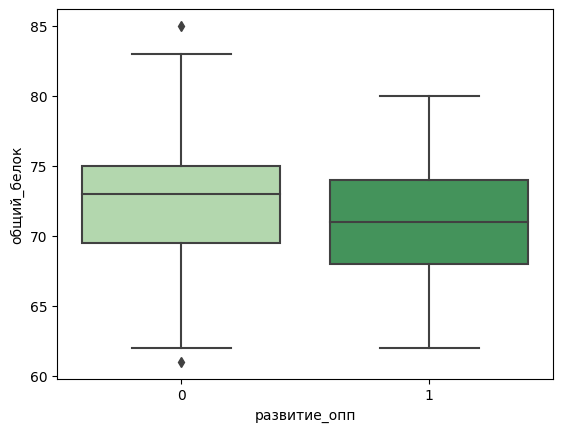

In [ ]:
hypo_7(df)


Гипотеза 7 подтверждена по критерию Стьюдента.

Критерий: Хи-квадрат
Статистика:1.423, p-уровень:0.2329


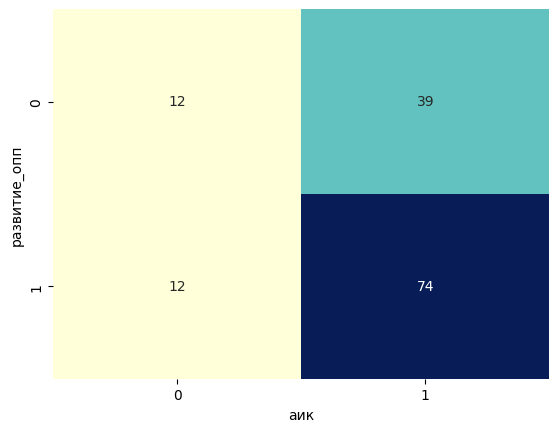

In [ ]:
hypo_8(df)


Гипотеза 8 не подтверждена.

Критерий: Манна-Уитни
Статистика:-16.7063, p-уровень:0.0
Точечно-бисериальная корреляция
Статистика:0.0757, p-уровень:0.3791


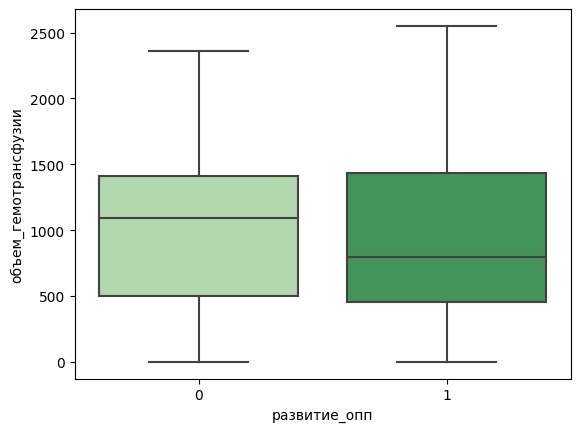

In [ ]:
hypo_9(df)


Гипотеза 10 подтверждена по критерию Манна-Уитни.

Критерий: Манна-Уитни
Статистика:-23.9239, p-уровень:0.0
Точечно-бисериальная корреляция
Статистика:0.0757, p-уровень:0.3791


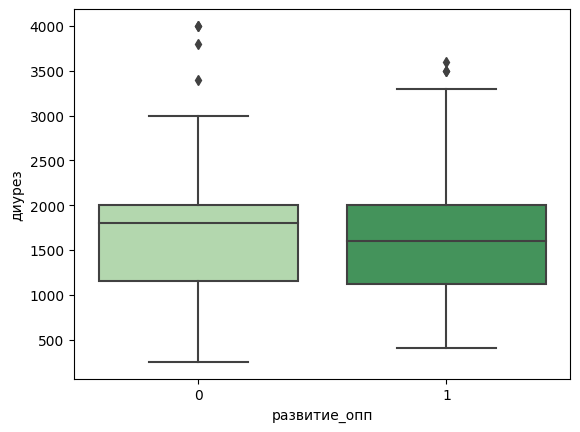

In [ ]:
hypo_10(df)


Гипотеза 10 подтверждена по критерию Манна-Уитни.

## 5. Регрессионная модель

Обучение модели, вывод RMSE и сравнение с DummyRegressor из Sklearn

In [ ]:
def fit_model(X: np.array, y: np.array, n_estimators=10000, max_depth=3, random_seed=42) -> CatBoostRegressor:
    regressor = CatBoostRegressor(n_estimators=n_estimators, max_depth=max_depth, learning_rate=0.001, random_seed=random_seed)
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)
    regressor.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot_file="train.html")
    print(f"RMSE при  определении СКФ: {mean_squared_error(regressor.predict(X_test), y_test) ** 0.5}")
    dummy = DummyRegressor()
    dummy.fit(X_train, y_train)
    print(f"RMSE при  определении СКФ с помощью DummyRegressor: {mean_squared_error(dummy.predict(X_test), y_test) ** 0.5}")
    regressor.save_model("regressor.cbm")
    print("Модель сохранена как regressor.cbm")
    return regressor


Функция для предсказания значения СКФ

In [ ]:
def predict(X: np.array, model="regressor.cbm") -> float:
    regressor = CatBoostRegressor()
    regressor.load_model(model)
    return regressor.predict(X)


Приемр обучения модели

In [ ]:
model = fit_model(df[['возраст', 'пол', 'гб', 'сахарный_диабет',
'стенокардия', 'инфаркт_миокарда', 'мерцательная_аритмия',
'желудочковая_экстрасистолия', 'а-в_блокада',
'блокада_ножек_пучка_гиса', 'сад', 'дад', 'креатинин_крови',
'мочевина', 'калий', 'натрий', 'хлориды', 'кальций', 'рн',
'ве', 'нсо3', 'ро2', 'рсо2', 'оксигем.', 'общ.со2', 'гемоглобин',
'лейкоциты_крови', 'тромбоциты', 'холестерин',
'триглицериды', 'лпонп', 'лпнп', 'общий_белок', 'имт']], df[['скф_расч.']])

0:	learn: 25.2240147	test: 32.6654301	best: 32.6654301 (0)	total: 138ms	remaining: 23m 1s
1:	learn: 25.2132564	test: 32.6549226	best: 32.6549226 (1)	total: 139ms	remaining: 11m 32s
2:	learn: 25.2034119	test: 32.6489007	best: 32.6489007 (2)	total: 139ms	remaining: 7m 43s
3:	learn: 25.1916920	test: 32.6374258	best: 32.6374258 (3)	total: 139ms	remaining: 5m 48s
4:	learn: 25.1815024	test: 32.6366360	best: 32.6366360 (4)	total: 140ms	remaining: 4m 39s
5:	learn: 25.1726474	test: 32.6356068	best: 32.6356068 (5)	total: 140ms	remaining: 3m 53s
6:	learn: 25.1651790	test: 32.6304621	best: 32.6304621 (6)	total: 140ms	remaining: 3m 20s
7:	learn: 25.1569453	test: 32.6236989	best: 32.6236989 (7)	total: 141ms	remaining: 2m 55s
8:	learn: 25.1484618	test: 32.6181835	best: 32.6181835 (8)	total: 141ms	remaining: 2m 36s
9:	learn: 25.1396240	test: 32.6119327	best: 32.6119327 (9)	total: 141ms	remaining: 2m 21s
10:	learn: 25.1301855	test: 32.6039092	best: 32.6039092 (10)	total: 142ms	remaining: 2m 8s
11:	lear